In [1]:
import pandas as pd 
import numpy as np 
from numpy.lib.stride_tricks import sliding_window_view
import torch 
import torch.nn as nn 
from torch.utils.data import TensorDataset, DataLoader
from pytorch_tcn import TCN 

import matplotlib.pyplot as plt 
import gymnasium as gym
from gymnasium import spaces

from sklearn.preprocessing import StandardScaler
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnNoModelImprovement

In [2]:
stocks_df = pd.read_csv("sp500_stocks.csv") 

In [3]:
# hyper-y parameters on features we want 
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu") 
LOOKBACK = 30 # how many previous days of data we get 
FEATURES = ["open", "high", "low", "close", "volume"] # nothing, just lagged columns 
HORIZONS = [1, 7, 30] # these are in trading days, not calendar days. Could possibly cause some problems later 
                             # this will actually change in the target columns of the data loader if you care to customize in this way 

BATCH_SIZE = 64 
HMAX = max(HORIZONS)

df = stocks_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol","date"]).reset_index(drop=True)

Xl, yl = [], []

for _, g in df.groupby("symbol", sort=False):
    x = g[FEATURES].to_numpy(np.float32)

    ### Normazlizing; especially important for volume, because otherwise loss explodes and has no way of coming down 
    mu = x.mean(axis=0)
    sigma = x.std(axis=0) + 1e-8
    x = (x - mu) / sigma
    c = g["close"].to_numpy(np.float32)
    T = len(g)
    if T < LOOKBACK + HMAX: 
        continue

    w = sliding_window_view(x, LOOKBACK, axis=0)
    n = T - LOOKBACK - HMAX + 1
    if n <= 0:
        continue

    X = w[:n].transpose(0,2,1)
    b = c[LOOKBACK-1:LOOKBACK-1+n]

    y = np.stack([(c[LOOKBACK-1+h:LOOKBACK-1+h+n]/b - 1) for h in HORIZONS],1).astype(np.float32)

    Xl.append(X); yl.append(y)

X = torch.tensor(np.concatenate(Xl), dtype=torch.float32)
y = torch.tensor(np.concatenate(yl), dtype=torch.float32)

n = len(X)
idx = torch.arange(n)

first_cutoff = int(0.7*n)
second_cutoff = int(0.9*n)

train = TensorDataset(X[:first_cutoff], y[:first_cutoff])
val   = TensorDataset(X[first_cutoff:second_cutoff], y[first_cutoff:second_cutoff])
test  = TensorDataset(X[second_cutoff:], y[second_cutoff])

train_loader = DataLoader(train, BATCH_SIZE, shuffle=True, drop_last=True, num_workers = 4, persistent_workers = True, pin_memory = True)
val_loader   = DataLoader(val, BATCH_SIZE)
test_loader  = DataLoader(test, BATCH_SIZE)

In [ ]:
### DO NOT RUN THIS CELL UNLESS YOU WANT A VERY EXPENSIVE MODEL RUN 

EPOCHS = 3 
LR = 3e-4 
WEIGHT_DECAY = 2e-6 


model = TCN(
    num_inputs = 5, # one channel for each feature we have 
    num_channels = [16, 32, 64, 64],
    dilation_reset = 32, # to stop the kernels from trying to expand beyond the length of the inputs they're getting (default is dilation works as 2^n) 
    kernel_size = 3,
    dropout = 0.1,
    causal = True,
    use_skip_connections = True,
    output_projection = 3,
    input_shape = "NLC", 
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY   # L2 regularization
)


train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_train_loss = 0.0

    for step, (X_batch, y_batch) in enumerate(train_loader):

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

        train_losses.append(loss.item())


        if not step % 500: 
            print(
                f"Epoch {epoch+1}/{EPOCHS} | "
                f"Step {step}/{len(train_loader)} | "
                f"Train Loss: {loss.item():.6f}"
            )

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)

            preds = output[:, -1, :]

            loss = criterion(preds, y_batch)

            running_val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1} Complete | "
        f"Avg Train Loss: {avg_train_loss:.6f} | "
        f"Avg Val Loss: {avg_val_loss:.6f}\n"
    )


/opt/homebrew/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/3 | Step 0/31646 | Train Loss: 0.091669
Epoch 1/3 | Step 500/31646 | Train Loss: 0.010468
Epoch 1/3 | Step 1000/31646 | Train Loss: 0.006181
Epoch 1/3 | Step 1500/31646 | Train Loss: 0.004953
Epoch 1/3 | Step 2000/31646 | Train Loss: 0.006746
Epoch 1/3 | Step 2500/31646 | Train Loss: 0.004653
Epoch 1/3 | Step 3000/31646 | Train Loss: 0.002975
Epoch 1/3 | Step 3500/31646 | Train Loss: 0.004939
Epoch 1/3 | Step 4000/31646 | Train Loss: 0.005471
Epoch 1/3 | Step 4500/31646 | Train Loss: 0.009064
Epoch 1/3 | Step 5000/31646 | Train Loss: 0.004511
Epoch 1/3 | Step 5500/31646 | Train Loss: 0.004512
Epoch 1/3 | Step 6000/31646 | Train Loss: 0.006340
Epoch 1/3 | Step 6500/31646 | Train Loss: 0.004289
Epoch 1/3 | Step 7000/31646 | Train Loss: 0.007481
Epoch 1/3 | Step 7500/31646 | Train Loss: 0.007070
Epoch 1/3 | Step 8000/31646 | Train Loss: 0.005154
Epoch 1/3 | Step 8500/31646 | Train Loss: 0.003695
Epoch 1/3 | Step 9000/31646 | Train Loss: 0.006413
Epoch 1/3 | Step 9500/31646 | Train

In [ ]:
'''torch.save(
    {
        "model_state": model.state_dict(),
        "config": {
            "num_inputs": 5,
            "num_channels": [16, 32, 64, 64],
            "kernel_size": 3,
            "dropout": 0.1,
            "causal": True,
            "use_skip_connections": True,
            "output_projection": 3,
            "input_shape": "NLC",
        }
    },
    "tcn_model_small_winner2.pt"
)'''

'''## If needed later: 
ckpt = torch.load("tcn_model_small_winner.pt2", map_location=DEVICE)

model = TCN(**ckpt["config"]).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()'''

'## If needed later: \nckpt = torch.load("tcn_model_small_winner.pt", map_location=DEVICE)\n\nmodel = TCN(**ckpt["config"]).to(DEVICE)\nmodel.load_state_dict(ckpt["model_state"])\nmodel.eval()'

In [13]:
# Code for evaluating the model (credit to GPT for this one) 
model.eval()

df = stocks_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

df["next_ret"] = df.groupby("symbol")["close"].shift(-1) / df["close"] - 1
df = df.dropna(subset=["next_ret"])

groups = {
    s: {
        "x": g[FEATURES].to_numpy(np.float32),
        "ret": g["next_ret"].to_numpy(np.float32),
        "date": g["date"].to_numpy()
    }
    for s, g in df.groupby("symbol")
}

dates = sorted(df["date"].unique())

top10_r, eq_r = [], []

for d in dates:

    X_list, R_list = [], []

    for s, g in groups.items():

        dates_s = g["date"]
        idx = np.where(dates_s == d)[0]

        if len(idx) == 0:
            continue

        i = idx[0]
        if i < 30:
            continue

        x = g["x"][i-30:i]          # (30, 5)
        r = g["ret"][i]

        # enforce shape safety
        if x.shape != (30, 5):
            continue

        mu = x.mean(axis=0)
        std = x.std(axis=0) + 1e-8
        x = (x - mu) / std

        X_list.append(x)
        R_list.append(r)

    if len(X_list) < 10:
        continue


    X = np.stack(X_list)  # (N, 30, 5)
    R = np.array(R_list)

    assert X.shape[1:] == (30, 5)

    X = torch.tensor(X, dtype=torch.float32, device=DEVICE)


    with torch.no_grad():
        preds = model(X)[:, -1, 0].cpu().numpy()  # (N,)


    top_idx = np.argsort(preds)[-10:]

    top10_r.append(R[top_idx].mean())
    eq_r.append(R.mean())


top10_curve = np.cumprod(1 + np.array(top10_r)) - 1
eq_curve = np.cumprod(1 + np.array(eq_r)) - 1

plt.figure(figsize=(10,5))
plt.plot(top10_curve, label="TCN Top-10")
plt.plot(eq_curve, label="Equal Weight")
plt.legend()
plt.grid()
plt.show()

KeyboardInterrupt: 

In [4]:
### SAME THING AGAIN, BUT ONLY ON RECENT DATA + 50 LARGEST STOCKS 
### THIS IS THE TRAINING LOOP TO RUN 
rec_popdf = df.copy() 

# Same 50 large-cap tickers used in supervised models.ipynb
tickers = [
    "NVDA","GOOGL","AAPL","MSFT","AMZN",
    "META","AVGO","TSLA","BRK-B","LLY",
    "JPM","V","XOM","MA","UNH",
    "JNJ","PG","COST","HD","CVX",
    "ABBV","PEP","KO","MRK","CSCO",
    "ADBE","CRM","ORCL","NFLX","WMT",
    "MCD","TMO","AMD","INTC","ACN",
    "IBM","QCOM","TXN","AXP","GS",
    "MS","BLK","SPGI","INTU","BKNG",
    "SBUX","NKE","RTX","LMT","GE"
]

start_date = pd.to_datetime("2016-04-30")
end_date = pd.to_datetime("2026-04-30") 

rec_popdf = rec_popdf[
    (rec_popdf["date"] >= start_date)
    & (rec_popdf["date"] <= end_date)
    & (rec_popdf["symbol"].isin(tickers))
].reset_index()

Xl, yl = [], []

for _, g in rec_popdf.groupby("symbol", sort=False):
    x = g[FEATURES].to_numpy(np.float32)

    ### Normalizing; especially important for volume, because otherwise loss explodes and has no way of coming down 
    mu = x.mean(axis=0)
    sigma = x.std(axis=0) + 1e-8
    x = (x - mu) / sigma
    c = g["close"].to_numpy(np.float32)
    T = len(g)
    if T < LOOKBACK + HMAX: 
        continue

    w = sliding_window_view(x, LOOKBACK, axis=0)
    n = T - LOOKBACK - HMAX + 1
    if n <= 0:
        continue

    X = w[:n].transpose(0,2,1)
    b = c[LOOKBACK-1:LOOKBACK-1+n]

    y = np.stack([(c[LOOKBACK-1+h:LOOKBACK-1+h+n]/b - 1) for h in HORIZONS], 1).astype(np.float32)

    Xl.append(X); yl.append(y)

X = torch.tensor(np.concatenate(Xl), dtype=torch.float32)
y = torch.tensor(np.concatenate(yl), dtype=torch.float32)

n = len(X)
idx = torch.arange(n)

first_cutoff = int(0.7*n)
second_cutoff = int(0.9*n)

train = TensorDataset(X[:first_cutoff], y[:first_cutoff])
val   = TensorDataset(X[first_cutoff:second_cutoff], y[first_cutoff:second_cutoff])
test  = TensorDataset(X[second_cutoff:], y[second_cutoff])

train_loader = DataLoader(train, BATCH_SIZE, shuffle=True, drop_last=True, num_workers = 4, persistent_workers = True, pin_memory = True)
val_loader   = DataLoader(val, BATCH_SIZE)
test_loader  = DataLoader(test, BATCH_SIZE)

In [13]:
EPOCHS = 3 
LR = 3e-4 
WEIGHT_DECAY = 2e-6 


model = TCN(
    num_inputs = 5, # one channel for each feature we have 
    num_channels = [16, 72, 72, 72],
    dilation_reset = 32, # to stop the kernels from trying to expand beyond the length of the inputs they're getting (default is dilation works as 2^n) 
    kernel_size = 3,
    dropout = 0.1,
    causal = True,
    use_skip_connections = True,
    output_projection = 3,
    input_shape = "NLC", 
).to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY   # L2 regularization
)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for step, (X_batch, y_batch) in enumerate(train_loader):
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        output = model(X_batch)
        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        train_losses.append(loss.item())

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            output = model(X_batch)
            preds = output[:, -1, :]
            loss = criterion(preds, y_batch)

            running_val_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = running_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)

    print(
        f"\nEpoch {epoch+1} Complete | "
        f"Avg Train Loss: {avg_train_loss:.6f} | "
        f"Avg Val Loss: {avg_val_loss:.6f}\n"
    )

'''model.eval()

test_loss = 0.0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        output = model(X_batch)

        preds = output[:, -1, :]

        loss = criterion(preds, y_batch)

        test_loss += loss.item()

test_loss /= len(test_loader)

print(f"Test Loss: {test_loss:.6f}")'''


Epoch 1 Complete | Avg Train Loss: 0.006010 | Avg Val Loss: 0.006440


Epoch 2 Complete | Avg Train Loss: 0.004307 | Avg Val Loss: 0.006354


Epoch 3 Complete | Avg Train Loss: 0.004240 | Avg Val Loss: 0.006343



'model.eval()\n\ntest_loss = 0.0\n\nwith torch.no_grad():\n\n    for X_batch, y_batch in test_loader:\n\n        X_batch = X_batch.to(DEVICE)\n        y_batch = y_batch.to(DEVICE)\n\n        output = model(X_batch)\n\n        preds = output[:, -1, :]\n\n        loss = criterion(preds, y_batch)\n\n        test_loss += loss.item()\n\ntest_loss /= len(test_loader)\n\nprint(f"Test Loss: {test_loss:.6f}")'

In [ ]:
checkpoint = torch.load("tcn_model_small_winner.pt", map_location=DEVICE)

model = TCN(**checkpoint["config"]).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

RuntimeError: Error(s) in loading state_dict for TCN:
	Missing key(s) in state_dict: "downsample_skip_connection.1.weight", "downsample_skip_connection.1.bias", "network.2.downsample.weight", "network.2.downsample.bias". 
	size mismatch for downsample_skip_connection.0.weight: copying a param with shape torch.Size([72, 16, 1]) from checkpoint, the shape in current model is torch.Size([64, 16, 1]).
	size mismatch for downsample_skip_connection.0.bias: copying a param with shape torch.Size([72]) from checkpoint, the shape in current model is torch.Size([64]).
	size mismatch for network.1.conv1.bias: copying a param with shape torch.Size([72]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for network.1.conv1.parametrizations.weight.original0: copying a param with shape torch.Size([72, 1, 1]) from checkpoint, the shape in current model is torch.Size([32, 1, 1]).
	size mismatch for network.1.conv1.parametrizations.weight.original1: copying a param with shap

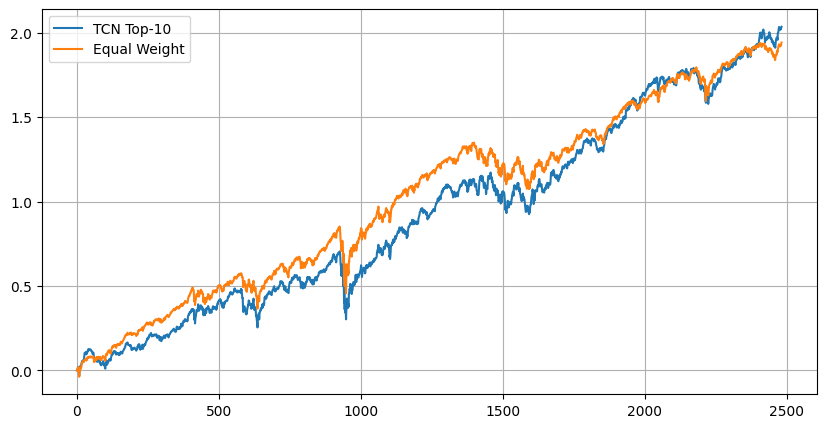

In [14]:
# Code for evaluating the model (full credit to ChatGPT here): 
model.eval()

graphing_df = rec_popdf.copy()
graphing_df["date"] = pd.to_datetime(graphing_df["date"])
graphing_df = graphing_df.sort_values(["symbol", "date"]).reset_index(drop=True)

graphing_df["next_ret"] = graphing_df.groupby("symbol")["close"].shift(-1) / graphing_df["close"] - 1
graphing_df = graphing_df.dropna(subset=["next_ret"])

groups = {
    s: {
        "x": g[FEATURES].to_numpy(np.float32),
        "ret": g["next_ret"].to_numpy(np.float32),
        "date": g["date"].to_numpy()
    }
    for s, g in graphing_df.groupby("symbol")
}

dates = sorted(graphing_df["date"].unique())

top10_r, eq_r = [], []

for d in dates:

    X_list, R_list = [], []

    for s, g in groups.items():

        dates_s = g["date"]
        idx = np.where(dates_s == d)[0]

        if len(idx) == 0:
            continue

        i = idx[0]
        if i < 30:
            continue

        x = g["x"][i-30:i]          # (30, 5)
        r = g["ret"][i]

        # enforce shape safety
        if x.shape != (30, 5):
            continue

        mu = x.mean(axis=0)
        std = x.std(axis=0) + 1e-8
        x = (x - mu) / std

        X_list.append(x)
        R_list.append(r)

    if len(X_list) < 10:
        continue


    X = np.stack(X_list)  # (N, 30, 5)
    R = np.array(R_list)

    assert X.shape[1:] == (30, 5)

    X = torch.tensor(X, dtype=torch.float32, device=DEVICE)


    with torch.no_grad():
        preds = model(X)[:, -1, 0].cpu().numpy()  # (N,)


    top_idx = np.argsort(preds)[-10:]

    top10_r.append(R[top_idx].mean())
    eq_r.append(R.mean())


top10_curve = np.log(np.cumprod(1 + np.array(top10_r))) 
eq_curve = np.log(np.cumprod(1 + np.array(eq_r))) 

plt.figure(figsize=(10,5))
plt.plot(top10_curve, label="TCN Top-10")
plt.plot(eq_curve, label="Equal Weight")
plt.legend()
plt.grid()
plt.show()

In [15]:
### USING TCN AS INPUT TO PPO 
LOOKBACK = 30
FEATURES = ["open", "high", "low", "close", "volume"]
DURATIONS = [1, 7, 30]

df = rec_popdf.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

for d in DURATIONS:
    df[f"ret_{d}d"] = (
        df.groupby("symbol")["close"].shift(-d) / df["close"] - 1
    )

groups = {
    s: g.reset_index(drop=True)
    for s, g in df.groupby("symbol")
}

dates = sorted(
    set.intersection(*[
        set(g["date"].iloc[LOOKBACK:-max(DURATIONS)])
        for g in groups.values()
    ])
)

X_raw, R = [], []

for d in dates:

    X_day, R_day = [], []
    valid = True

    for s in tickers:

        g = groups[s]

        idx = np.where(g["date"].values == d)[0]
        if len(idx) == 0:
            valid = False
            break

        i = idx[0]

        if i < LOOKBACK or i + max(DURATIONS) >= len(g):
            valid = False
            break

        x = g.loc[i-LOOKBACK:i-1, FEATURES].to_numpy(np.float32)
        r = g.loc[i, "ret_1d"]

        if x.shape != (LOOKBACK, 5):
            valid = False
            break

        X_day.append(x)
        R_day.append(r)

    if valid:
        X_raw.append(np.stack(X_day))
        R.append(np.array(R_day, dtype=np.float32))

X_raw = np.stack(X_raw)   # (T, 50, 30, 5)
R = np.stack(R)

# Train-test split 
n = len(X_raw)

train_end = int(n * 0.70)
val_end = int(n * 0.90)

train_raw = X_raw[:train_end]
val_raw = X_raw[train_end:val_end]
test_raw = X_raw[val_end:]

train_ret = R[:train_end]
val_ret = R[train_end:val_end]
test_ret = R[val_end:]

# Standardizing the data using only information from the training set 
mu = train_raw.mean(axis=(0,1,2), keepdims=True)
sd = train_raw.std(axis=(0,1,2), keepdims=True) + 1e-8

train_raw = (train_raw - mu) / sd
val_raw = (val_raw - mu) / sd
test_raw = (test_raw - mu) / sd

# Making predictions using the TCN model 
model.eval()

def make_preds(X):
    preds = []
    with torch.no_grad():
        for i in range(len(X)):
            x = torch.tensor(
                X[i],
                dtype=torch.float32,
                device=DEVICE
            )                       # (50, 30, 5)

            p = model(x)[:, -1, :] # (50, 3)
            preds.append(p.cpu().numpy().astype(np.float32))

    return np.stack(preds)

train_pred = make_preds(train_raw)
val_pred = make_preds(val_raw)
test_pred = make_preds(test_raw)

# Making dataloaders (raw is the 30x5 datapoints for each stock, pred is using the predicted values from the TCN) 


In [16]:
class PortfolioAllocationEnv(gym.Env):
    """Long-only, fully invested daily allocation env.

    Observation: flattened 50 x 61 feature panel plus previous 50-stock weights.
    Action: 50 unconstrained logits, converted to long-only weights with softmax.
    Reward: next-day net portfolio simple return after transaction cost.
    """

    metadata = {"render_modes": []}

    def __init__(self, panel, cost_bps=5, initial_weights="equal"):
        super().__init__()
        self.X = panel["X"].astype(np.float32)
        self.returns = panel["returns"].astype(np.float32)
        self.source_dates = panel["source_dates"]
        self.target_dates = panel["target_dates"]
        self.symbols = panel["symbols"]
        self.cost_bps = float(cost_bps)
        self.initial_weights = initial_weights

        self.n_steps, self.n_assets, self.n_features = self.X.shape
        obs_dim = self.n_assets * self.n_features + self.n_assets

        self.observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(obs_dim,),
            dtype=np.float32,
        )
        self.action_space = spaces.Box(
            low=-10.0,
            high=10.0,
            shape=(self.n_assets,),
            dtype=np.float32,
        )

        self.reset()

    def _initial_weights(self):
        return np.full(self.n_assets, 1.0 / self.n_assets, dtype=np.float32)

    @staticmethod
    def _softmax(action):
        action = np.asarray(action, dtype=np.float64)
        action = action - np.max(action)
        exp_action = np.exp(action)
        weights = exp_action / (exp_action.sum() + 1e-12)
        return weights.astype(np.float32)

    def _get_obs(self):
        features = self.X[self.idx].reshape(-1)
        return np.concatenate([features, self.prev_weights], axis=0).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.idx = 0
        self.prev_weights = self._initial_weights()
        self.nav = 1.0
        return self._get_obs(), {}

    def step(self, action):
        weights = self._softmax(action)
        asset_returns = self.returns[self.idx]

        gross_return = float(np.dot(weights, asset_returns))
        turnover = float(np.abs(weights - self.prev_weights).sum())
        cost = turnover * self.cost_bps / 10000.0
        net_return = gross_return - cost

        self.nav *= (1.0 + net_return)

        info = {
            "source_date": self.source_dates[self.idx],
            "target_date": self.target_dates[self.idx],
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "nav": self.nav,
            "weights": weights.copy(),
        }

        self.prev_weights = weights
        self.idx += 1
        terminated = self.idx >= self.n_steps
        truncated = False

        if terminated:
            obs = np.zeros(self.observation_space.shape, dtype=np.float32)
        else:
            obs = self._get_obs()

        return obs, net_return, terminated, truncated, info


def make_env(panel, cost_bps=5):
    return Monitor(PortfolioAllocationEnv(panel, cost_bps=cost_bps))



train_raw_flat = train_raw.reshape(len(train_raw), 50, -1)
val_raw_flat   = val_raw.reshape(len(val_raw), 50, -1)
test_raw_flat  = test_raw.reshape(len(test_raw), 50, -1)

all_dates = np.array(dates)

train_dates_used = all_dates[:train_end]
val_dates_used   = all_dates[train_end:val_end]
test_dates_used  = all_dates[val_end:]

# target dates = next trading day
train_target_dates = train_dates_used[1:]
val_target_dates   = val_dates_used[1:]
test_target_dates  = test_dates_used[1:]

# trim final timestep so source/target align
train_raw_flat = train_raw_flat[:-1]
val_raw_flat   = val_raw_flat[:-1]
test_raw_flat  = test_raw_flat[:-1]

train_pred = train_pred[:-1]
val_pred   = val_pred[:-1]
test_pred  = test_pred[:-1]

train_ret = train_ret[:-1]
val_ret   = val_ret[:-1]
test_ret  = test_ret[:-1]

train_raw_panel = {
    "X": train_raw_flat.astype(np.float32),
    "returns": train_ret.astype(np.float32),
    "source_dates": train_dates_used[:-1],
    "target_dates": train_target_dates,
    "symbols": tickers,
}

val_raw_panel = {
    "X": val_raw_flat.astype(np.float32),
    "returns": val_ret.astype(np.float32),
    "source_dates": val_dates_used[:-1],
    "target_dates": val_target_dates,
    "symbols": tickers,
}

test_raw_panel = {
    "X": test_raw_flat.astype(np.float32),
    "returns": test_ret.astype(np.float32),
    "source_dates": test_dates_used[:-1],
    "target_dates": test_target_dates,
    "symbols": tickers,
}

train_pred_panel = {
    "X": train_pred.astype(np.float32),
    "returns": train_ret.astype(np.float32),
    "source_dates": train_dates_used[:-1],
    "target_dates": train_target_dates,
    "symbols": tickers,
}

val_pred_panel = {
    "X": val_pred.astype(np.float32),
    "returns": val_ret.astype(np.float32),
    "source_dates": val_dates_used[:-1],
    "target_dates": val_target_dates,
    "symbols": tickers,
}

test_pred_panel = {
    "X": test_pred.astype(np.float32),
    "returns": test_ret.astype(np.float32),
    "source_dates": test_dates_used[:-1],
    "target_dates": test_target_dates,
    "symbols": tickers,
}

train_raw_env = DummyVecEnv([
    lambda: make_env(train_raw_panel)
])

val_raw_env = DummyVecEnv([
    lambda: make_env(val_raw_panel)
])

test_raw_env = DummyVecEnv([
    lambda: make_env(test_raw_panel)
])

train_pred_env = DummyVecEnv([
    lambda: make_env(train_pred_panel)
])

val_pred_env = DummyVecEnv([
    lambda: make_env(val_pred_panel)
])

test_pred_env = DummyVecEnv([
    lambda: make_env(test_pred_panel)
])


In [17]:
policy_kwargs = dict(net_arch=dict(pi=[512, 512, 256], vf=[512, 512, 256]))

model_on_raw = PPO(
    "MlpPolicy",
    train_raw_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    seed=42,
    verbose=1,
)

model_on_pred = PPO(
    "MlpPolicy",
    train_pred_env,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=256,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.001,
    vf_coef=0.5,
    max_grad_norm=0.5,
    policy_kwargs=policy_kwargs,
    seed=42,
    verbose=1,
)

# Can increase if desired 
TOTAL_TIMESTEPS = 70_000
model_on_raw.learn(total_timesteps=TOTAL_TIMESTEPS)
model_on_pred.learn(total_timesteps=TOTAL_TIMESTEPS) 

Using cpu device
Using cpu device
----------------------------
| time/              |     |
|    fps             | 773 |
|    iterations      | 1   |
|    time_elapsed    | 0   |
|    total_timesteps | 512 |
----------------------------
----------------------------------------
| time/                   |            |
|    fps                  | 542        |
|    iterations           | 2          |
|    time_elapsed         | 1          |
|    total_timesteps      | 1024       |
| train/                  |            |
|    approx_kl            | 0.04090207 |
|    clip_fraction        | 0.435      |
|    clip_range           | 0.2        |
|    entropy_loss         | -71        |
|    explained_variance   | -4.91      |
|    learning_rate        | 0.0003     |
|    loss                 | -0.172     |
|    n_updates            | 10         |
|    policy_gradient_loss | -0.0503    |
|    std                  | 1          |
|    value_loss           | 2.39       |
-------------------------

,strategy,start_date,end_date,days,total_return,ann_return,ann_vol,sharpe,max_drawdown,win_rate,avg_turnover,avg_cost
1,EqualWeight50_valid,2023-04-12,2025-03-25,490,0.546104,0.251188,0.124419,2.018889,-0.093943,0.573469,0.000000,0.000000
0,PPO_All50_LongOnly_valid,2023-04-12,2025-03-25,490,0.591561,0.269974,0.434812,0.620898,-0.398137,0.512245,0.004290,0.000002
2,PPO_All50_LongOnly_test,2025-03-27,2026-03-18,245,0.353161,0.364905,0.404943,0.901126,-0.189802,0.522449,0.007217,0.000004
3,EqualWeight50_test,2025-03-27,2026-03-18,245,0.145049,0.149489,0.177121,0.843994,-0.124682,0.575510,0.000000,0.000000


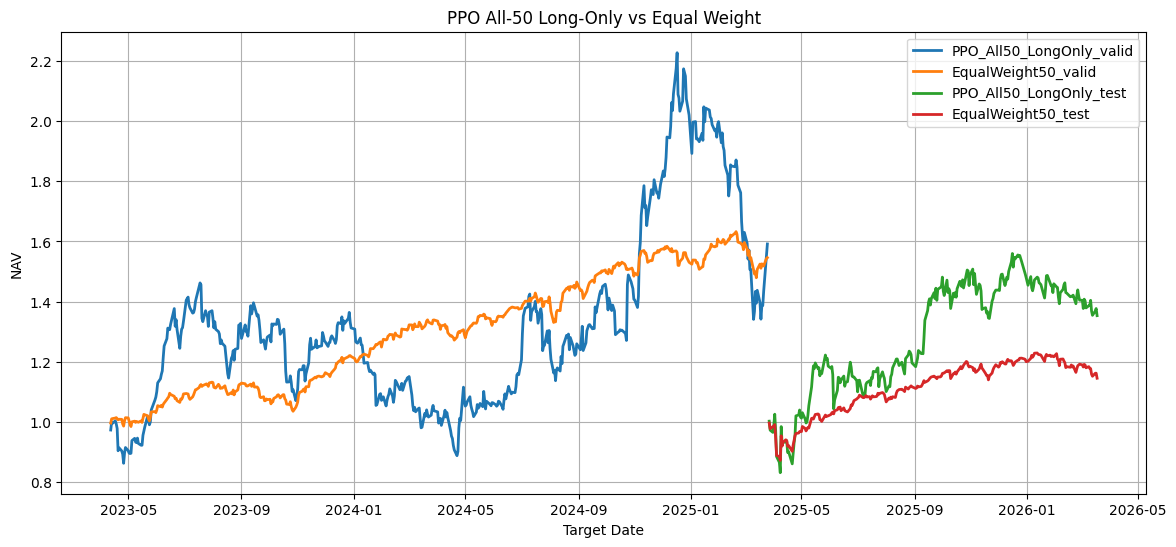

In [20]:
# Comparison to equal weighting using the 
def rollout_policy(model, panel, name, deterministic=True):
    env = PortfolioAllocationEnv(panel, cost_bps=5)
    obs, _ = env.reset()
    rows = []
    weight_rows = []

    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        rows.append({
            "date": info["source_date"],
            "target_date": info["target_date"],
            "gross_return": info["gross_return"],
            "turnover": info["turnover"],
            "cost": info["cost"],
            "net_return": info["net_return"],
            "nav": info["nav"],
            "strategy": name,
        })
        for symbol, weight in zip(panel["symbols"], info["weights"]):
            weight_rows.append({
                "date": info["source_date"],
                "target_date": info["target_date"],
                "symbol": symbol,
                "weight": float(weight),
                "strategy": name,
            })

    curve = pd.DataFrame(rows).set_index("target_date").sort_index()
    weights = pd.DataFrame(weight_rows)
    return curve, weights


def equal_weight_backtest(panel, name="EqualWeight50"):
    weights = np.full(len(panel["symbols"]), 1.0 / len(panel["symbols"]), dtype=np.float32)
    rows, weight_rows = [], []
    nav = 1.0
    prev_weights = np.full_like(weights, 1.0 / len(weights))

    for i in range(panel["returns"].shape[0]):
        gross_return = float(np.dot(weights, panel["returns"][i]))
        turnover = float(np.abs(weights - prev_weights).sum())
        cost = turnover * 5 / 10000.0
        net_return = gross_return - cost
        nav *= 1.0 + net_return

        rows.append({
            "date": panel["source_dates"][i],
            "target_date": panel["target_dates"][i],
            "gross_return": gross_return,
            "turnover": turnover,
            "cost": cost,
            "net_return": net_return,
            "nav": nav,
            "strategy": name,
        })
        for symbol, weight in zip(panel["symbols"], weights):
            weight_rows.append({
                "date": panel["source_dates"][i],
                "target_date": panel["target_dates"][i],
                "symbol": symbol,
                "weight": float(weight),
                "strategy": name,
            })
        prev_weights = weights.copy()

    curve = pd.DataFrame(rows).set_index("target_date").sort_index()
    weights_df = pd.DataFrame(weight_rows)
    return curve, weights_df


def metrics(curve, ann_factor=252):
    ret = curve["net_return"].dropna()
    n_days = len(ret)
    nav = curve["nav"]
    cummax = nav.cummax()
    drawdown = nav / cummax - 1.0
    total_return = nav.iloc[-1] - 1.0
    ann_return = nav.iloc[-1] ** (ann_factor / n_days) - 1.0
    ann_vol = ret.std(ddof=1) * np.sqrt(ann_factor)
    return {
        "strategy": curve["strategy"].iloc[0],
        "start_date": curve.index.min(),
        "end_date": curve.index.max(),
        "days": n_days,
        "total_return": total_return,
        "ann_return": ann_return,
        "ann_vol": ann_vol,
        "sharpe": ann_return / (ann_vol + 1e-12),
        "max_drawdown": drawdown.min(),
        "win_rate": (ret > 0).mean(),
        "avg_turnover": curve["turnover"].mean(),
        "avg_cost": curve["cost"].mean(),
    }

valid_ppo_curve, valid_ppo_weights = rollout_policy(model_on_raw, val_raw_panel, "PPO_All50_LongOnly_valid")
test_ppo_curve, test_ppo_weights = rollout_policy(model_on_raw, test_raw_panel, "PPO_All50_LongOnly_test")
valid_eq_curve, valid_eq_weights = equal_weight_backtest(val_raw_panel, "EqualWeight50_valid")
test_eq_curve, test_eq_weights = equal_weight_backtest(test_raw_panel, "EqualWeight50_test")

summary = pd.DataFrame([
    metrics(valid_ppo_curve),
    metrics(valid_eq_curve),
    metrics(test_ppo_curve),
    metrics(test_eq_curve),
])

display(summary.sort_values(["start_date", "sharpe"], ascending=[True, False]))

plt.figure(figsize=(14, 6))
for curve in [valid_ppo_curve, valid_eq_curve, test_ppo_curve, test_eq_curve]:
    plt.plot(curve.index, curve["nav"], label=curve["strategy"].iloc[0], linewidth=2)
plt.title("PPO All-50 Long-Only vs Equal Weight")
plt.xlabel("Target Date")
plt.ylabel("NAV")
plt.grid(True)
plt.legend()
plt.show()